<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1692 | Val: 410 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[EfficientNet-B0] Epoch   1/100 | LR: 1.00e-04 | train loss 1.2643 acc 0.504 | val loss 0.9887 acc 0.644 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.00e-04 | train loss 0.8351 acc 0.647 | val loss 0.6726 acc 0.739 *


[EfficientNet-B0] Epoch   3/100 | LR: 1.00e-04 | train loss 0.6903 acc 0.710 | val loss 0.6743 acc 0.727


[EfficientNet-B0] Epoch   4/100 | LR: 1.00e-04 | train loss 0.5366 acc 0.746 | val loss 0.4853 acc 0.795 *


...

[EfficientNet-B0] Epoch  24/100 | LR: 1.00e-05 | train loss 0.1863 acc 0.921 | val loss 0.3460 acc 0.880


[EfficientNet-B0] Epoch  25/100 | LR: 1.00e-05 | train loss 0.1568 acc 0.924 | val loss 0.3397 acc 0.871


[EfficientNet-B0] Epoch  26/100 | LR: 1.00e-05 | train loss 0.1427 acc 0.934 | val loss 0.3455 acc 0.876


[EfficientNet-B0] Epoch  27/100 | LR: 1.00e-05 | train loss 0.1345 acc 0.927 | val loss 0.3701 acc 0.866


[EfficientNet-B0] Epoch  28/100 | LR: 1.00e-05 | train loss 0.1576 acc 0.923 | val loss 0.3429 acc 0.880

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 28.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.3119)


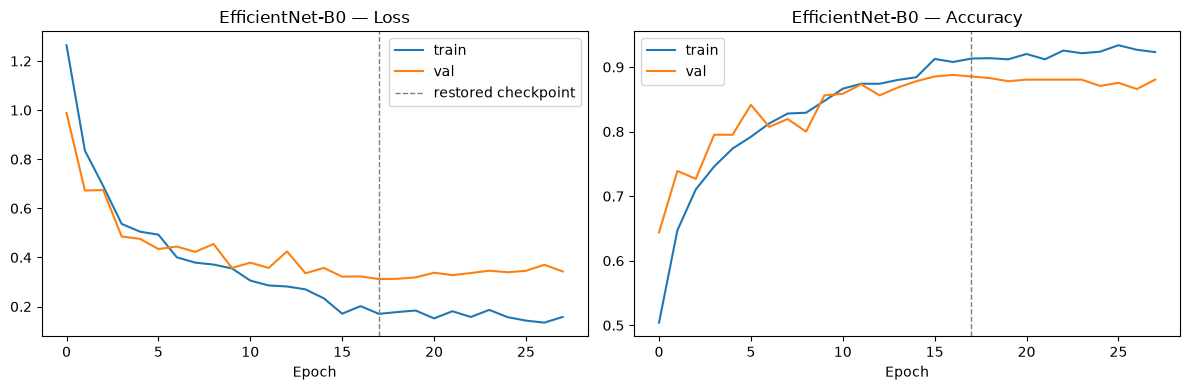

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.780


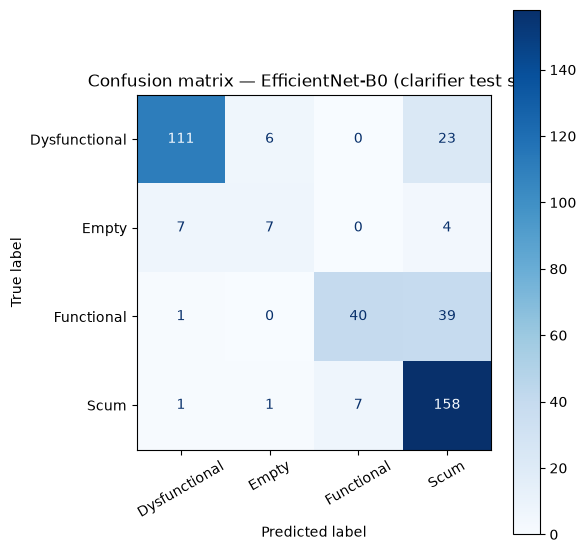

               precision    recall  f1-score   support

Dysfunctional      0.925     0.793     0.854       140
        Empty      0.500     0.389     0.438        18
   Functional      0.851     0.500     0.630        80
         Scum      0.705     0.946     0.808       167

     accuracy                          0.780       405
    macro avg      0.745     0.657     0.682       405
 weighted avg      0.801     0.780     0.772       405



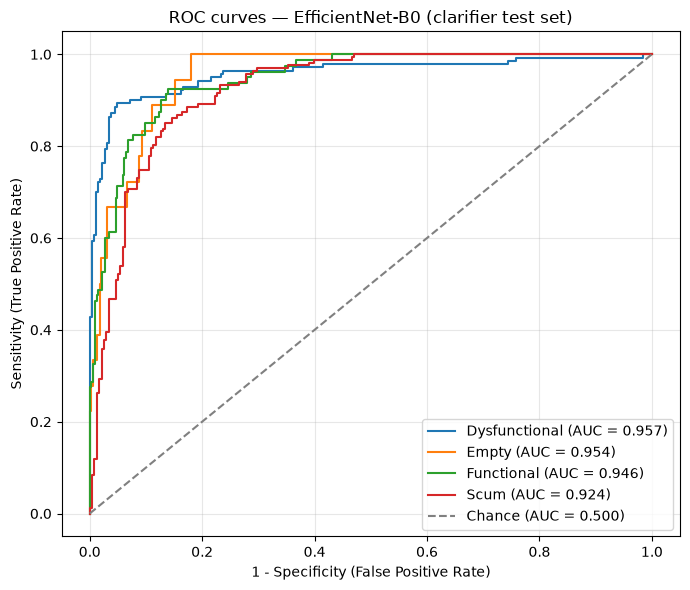

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.957
  Empty          : 0.954
  Functional     : 0.946
  Scum           : 0.924

Mean AUC (over 4/4 classes with test examples): 0.945


(np.float64(0.7802469135802469),
 {'Dysfunctional': 0.9571159029649595,
  'Empty': 0.9537754809072638,
  'Functional': 0.9463846153846154,
  'Scum': 0.9240175111960952})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/results_clarifier_efficientnet_b0_NoordelikeWerke.pkl


Saved model weights to ../models/clarifier_efficientnet_b0_cnn.pt
